# Project 4 — Deep Learning Systems

**Goal:** Train a CNN on the CNRPark parking-lot occupancy dataset and
compare a baseline model against an experimental variant that differs by
**exactly one change** (BatchNorm after every conv).

**Dataset:** [CNRPark](http://cnrpark.it/) (original, not EXT) — 150×150
RGB patches labeled `busy`/`free` by folder name. ~12.5k patches across two
cameras (A, B). License: research/educational; not committed to git.

**Models:**
- `BaselineCNN` — 3 conv blocks (32→64→128) + MaxPool, plain ReLU, no normalization.
- `ExperimentalCNN` — same architecture + `BatchNorm2d` after every conv.

**Loss / optimizer:** `BCEWithLogitsLoss`, `Adam(lr=1e-3)`.

**Split:** SEED=42 `random_split` → 80% train / 10% val / 10% test (both models see identical indices).

**Augmentation:** RandomHorizontalFlip + RandomVerticalFlip only — shared by both runs so the comparison isolates the architectural change.

**Reusability:** All dataset, model, and training code lives in `src/`. The notebook only orchestrates and visualizes.

## 1. Setup

Add `src/` to `sys.path` so the notebook can `import dataset`, `import models`, `import train` exactly as `train.py` does.

In [27]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()  # notebooks/ -> project_04_DeepLearning/
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn

import dataset  # src/dataset.py
import models   # src/models.py
import train    # src/train.py

sns.set_theme(style='whitegrid', context='notebook')
torch.manual_seed(dataset.SEED)
DEVICE = train.DEVICE
print('torch', torch.__version__, '| device', DEVICE)
print('patches_dir:', PROJECT_ROOT / 'data' / 'CNRPark-Patches-150x150')

torch 2.12.1+cpu | device cpu
patches_dir: D:\AI_Master\Udacity\capstone_projects\project_04_DeepLearning\data\CNRPark-Patches-150x150


## 2. Data exploration

Verify the on-disk layout, count per (camera, label), and confirm class balance.

In [28]:
PATCHES_DIR = PROJECT_ROOT / 'data' / 'CNRPark-Patches-150x150'
entries = dataset.scan_patches(PATCHES_DIR)
df = pd.DataFrame(
    [(str(p)[-81:], dataset.LABEL_MAP[p.parent.name.lower()], p.parent.parent.name) for p, _ in entries],
    columns=['path', 'label', 'camera'],
)
df['label_name'] = df['label'].map({0: 'free', 1: 'busy'})
print('total patches:', len(df))

df.sample(10, random_state=dataset.SEED)

total patches: 12584


,path,label,camera,label_name
11495,\project_04_DeepLearning\data\CNRPark-Patches-150x150\B\free\20150708_0900_41.jpg,0,B,free
6850,\project_04_DeepLearning\data\CNRPark-Patches-150x150\B\busy\20150708_1025_52.jpg,1,B,busy
11255,\project_04_DeepLearning\data\CNRPark-Patches-150x150\B\free\20150708_0835_25.jpg,0,B,free
7187,\project_04_DeepLearning\data\CNRPark-Patches-150x150\B\busy\20150708_1100_21.jpg,1,B,busy
5304,\project_04_DeepLearning\data\CNRPark-Patches-150x150\A\free\20150703_1525_20.jpg,0,A,free
11659,\project_04_DeepLearning\data\CNRPark-Patches-150x150\B\free\20150708_0925_32.jpg,0,B,free
5735,\project_04_DeepLearning\data\CNRPark-Patches-150x150\A\free\20150703_1705_11.jpg,0,A,free
6302,\project_04_DeepLearning\data\CNRPark-Patches-150x150\B\busy\20150708_0915_51.jpg,1,B,busy
396,\project_04_DeepLearning\data\CNRPark-Patches-150x150\A\busy\20150703_1010_14.jpg,1,A,busy
1655,s\project_04_DeepLearning\data\CNRPark-Patches-150x150\A\busy\20150703_1245_5.jpg,1,A,busy


In [29]:
counts = df.groupby(['camera', 'label_name']).size().unstack(fill_value=0)
counts['total'] = counts.sum(axis=1)
counts.loc['ALL'] = counts.sum()
counts

label_name,busy,free,total
camera,,,
A,3621,2550,6171
B,4781,1632,6413
ALL,8402,4182,12584


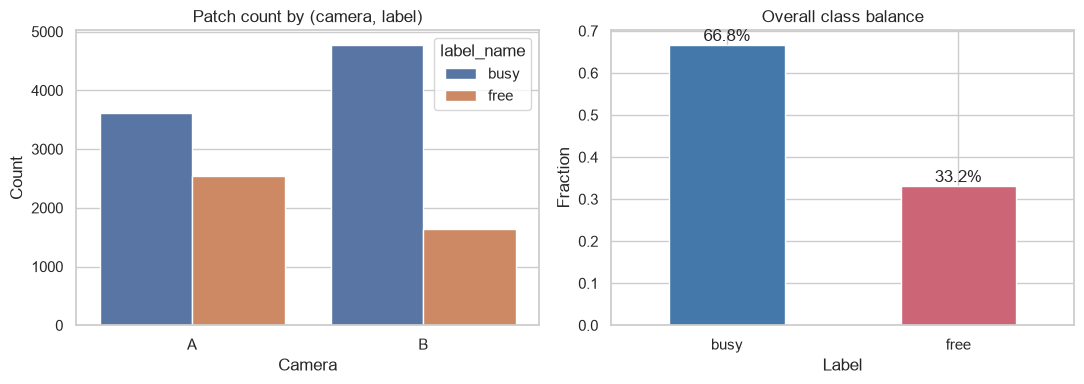

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=df, x='camera', hue='label_name', ax=ax[0])
ax[0].set_title('Patch count by (camera, label)')
ax[0].set_xlabel('Camera'); ax[0].set_ylabel('Count')

df['label_name'].value_counts(normalize=True).plot(kind='bar', ax=ax[1], color=['#4477AA', '#CC6677'])
ax[1].set_title('Overall class balance')
ax[1].set_xlabel('Label'); ax[1].set_ylabel('Fraction')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom')
plt.tight_layout(); plt.show()

**EDA takeaway:** ~12.5k patches, ~2:1 imbalance toward `busy` (`B/busy` is the dominant class).
A stratified split would be a follow-up; the baseline uses a SEED=42 random split (same split for both models).

## 3. Data loaders

Build train/val/test from `src.dataset.build_dataloaders`. Inspect one batch to confirm tensor shapes and label range.

In [31]:
BATCH_SIZE = 32
train_loader, val_loader, test_loader = dataset.build_dataloaders(
    PATCHES_DIR, batch_size=BATCH_SIZE, num_workers=0
)
print(f'train={len(train_loader.dataset)}  val={len(val_loader.dataset)}  test={len(test_loader.dataset)}')

xb, yb = next(iter(train_loader))
print('batch x:', xb.shape, xb.dtype, '  batch y:', yb.shape, yb.dtype,
      '  y range', float(yb.min()), float(yb.max()))

train=10068  val=1258  test=1258
batch x: torch.Size([32, 3, 150, 150]) torch.float32   batch y: torch.Size([32, 1]) torch.float32   y range 0.0 1.0


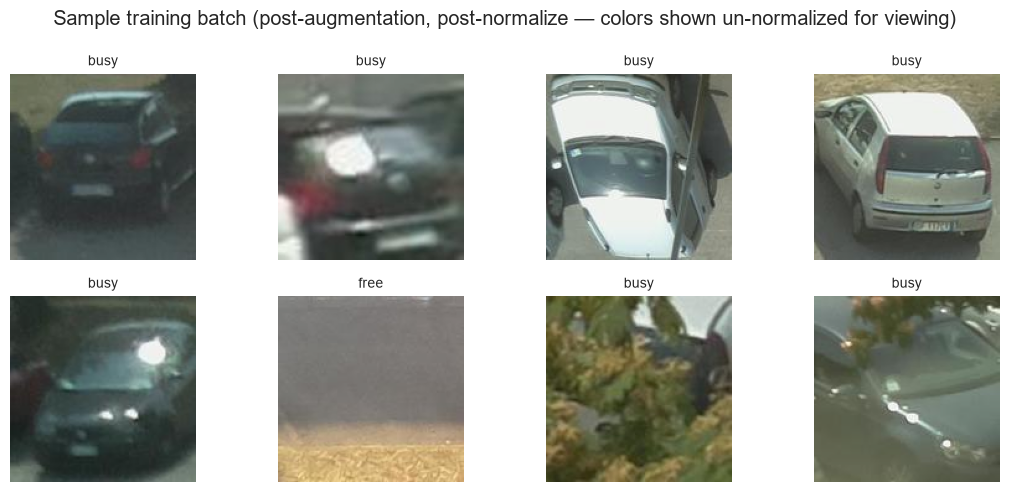

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    img = xb[i].permute(1, 2, 0).numpy()
    img = (img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))  # un-normalize
    img = np.clip(img, 0, 1)
    label = 'busy' if yb[i].item() == 1 else 'free'
    ax.imshow(img); ax.set_title(label, fontsize=10); ax.axis('off')
fig.suptitle('Sample training batch (post-augmentation, post-normalize — colors shown un-normalized for viewing)')
plt.tight_layout(); plt.show()

## 4. Models

Both models are defined in `src/models.py`. Confirm the **single architectural change** (BatchNorm after every conv) and that everything else (depth, channels, pooling, head) is identical.

In [33]:
baseline = models.BaselineCNN()
experimental = models.ExperimentalCNN()
print(f'BaselineCNN      params: {sum(p.numel() for p in baseline.parameters()):,}')
print(f'ExperimentalCNN  params: {sum(p.numel() for p in experimental.parameters()):,}')

# Forward a dummy batch through both -> must produce (B, 1).
_x = torch.zeros(2, 3, 150, 150)
for name, m in (('baseline', baseline), ('experimental', experimental)):
    out = m(_x)
    assert out.shape == (2, 1)
    print(f'{name}: forward OK -> {tuple(out.shape)}')

BaselineCNN      params: 5,401,921
ExperimentalCNN  params: 5,402,369
baseline: forward OK -> (2, 1)
experimental: forward OK -> (2, 1)


In [34]:
# Diff the architecture strings to make the ONE change explicit.
str_b = str(baseline.features)
str_e = str(experimental.features)
lines_b = [l.strip() for l in str_b.split('\n') if l.strip().startswith('(')]
lines_e = [l.strip() for l in str_e.split('\n') if l.strip().startswith('(')]
print(f"{'baseline':<55}  {'experimental (one change)':<55}")
for a, b in zip(lines_b, lines_e):
    marker = '  <-- DIFF' if a != b else ''
    print(f'{a[:55]:<55}  {b[:55]:<55}{marker}')

baseline                                                 experimental (one change)                              
(0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), p  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), p
(1): ReLU(inplace=True)                                  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=Tr  <-- DIFF
(2): MaxPool2d(kernel_size=2, stride=2, padding=0, dila  (2): ReLU(inplace=True)                                  <-- DIFF
(3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1),   (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dila  <-- DIFF
(4): ReLU(inplace=True)                                  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1),   <-- DIFF
(5): MaxPool2d(kernel_size=2, stride=2, padding=0, dila  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr  <-- DIFF
(6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1),  (6): ReLU(inplace=True)                                  <-- DIFF
(7): ReLU(inplace=True)             

## 5. Training

Run `train.fit()` on each model under identical settings. Per-epoch metrics are
saved to `reports/metrics_<name>.csv` (handled inside `train.main()`). For the
notebook we call `train.fit()` directly so we can also pull the trained model
back for the confusion matrix in §7.

> **Note:** A full 10-epoch run on CPU takes ~70 minutes. The cells below
> can be run with a smaller `EPOCHS` value for a quick smoke check; the
> default matches the planned final run. Set `EPOCHS = 1` for a fast sanity pass.

In [35]:
EPOCHS = 10
LR = 1e-3
print(f'epochs={EPOCHS}  batch_size={BATCH_SIZE}  lr={LR}  device={DEVICE}')

epochs=10  batch_size=32  lr=0.001  device=cpu


In [36]:
results = {}
for name in ('baseline', 'experimental'):
    print(f'\n--- training {name} ---')
    results[name] = train.fit(name, train_loader, val_loader, test_loader, EPOCHS, LR)


--- training baseline ---
[baseline] epoch  1/10  train_loss=0.2039 acc=0.9141  val_loss=0.1241 acc=0.9547  (206.9s)
[baseline] epoch  2/10  train_loss=0.1044 acc=0.9609  val_loss=0.1718 acc=0.9436  (173.4s)
[baseline] epoch  3/10  train_loss=0.0730 acc=0.9732  val_loss=0.0505 acc=0.9825  (169.2s)
[baseline] epoch  4/10  train_loss=0.0459 acc=0.9858  val_loss=0.0511 acc=0.9754  (159.8s)
[baseline] epoch  5/10  train_loss=0.0378 acc=0.9866  val_loss=0.0412 acc=0.9881  (159.0s)
[baseline] epoch  6/10  train_loss=0.0252 acc=0.9915  val_loss=0.0557 acc=0.9849  (149.5s)
[baseline] epoch  7/10  train_loss=0.0410 acc=0.9873  val_loss=0.0317 acc=0.9905  (164.3s)
[baseline] epoch  8/10  train_loss=0.0213 acc=0.9928  val_loss=0.0386 acc=0.9889  (185.9s)
[baseline] epoch  9/10  train_loss=0.0249 acc=0.9916  val_loss=0.0364 acc=0.9936  (177.6s)
[baseline] epoch 10/10  train_loss=0.0252 acc=0.9928  val_loss=0.0335 acc=0.9897  (178.4s)

--- training experimental ---
[experimental] epoch  1/10  trai

In [37]:
# Side-by-side test summary.
summary = pd.DataFrame([
    {'model': r['model_name'],
     'test_acc': r['test_acc'],
     'test_loss': r['test_loss'],
     'best_val_acc': r['best_val_acc']}
    for r in results.values()
])
summary

,model,test_acc,test_loss,best_val_acc
0,baseline,0.986486,0.037551,0.993641
1,experimental,0.988871,0.036060,0.990461


## 6. Learning curves

Per-epoch train/val loss and accuracy, side-by-side. Curves make it easy to
see whether BatchNorm converges faster, more stably, or to a higher floor.

In [38]:
hist_df = pd.concat(
    [pd.DataFrame(r['history']) for r in results.values()],
    ignore_index=True
)
hist_df.head()

,model,epoch,train_loss,train_acc,val_loss,val_acc,seconds
0,baseline,1,0.203940,0.914084,0.124138,0.954690,206.881050
1,baseline,2,0.104442,0.960866,0.171758,0.943561,173.375215
2,baseline,3,0.073018,0.973182,0.050499,0.982512,169.201308
3,baseline,4,0.045868,0.985797,0.051067,0.975358,159.826924
4,baseline,5,0.037765,0.986591,0.041203,0.988076,159.000973


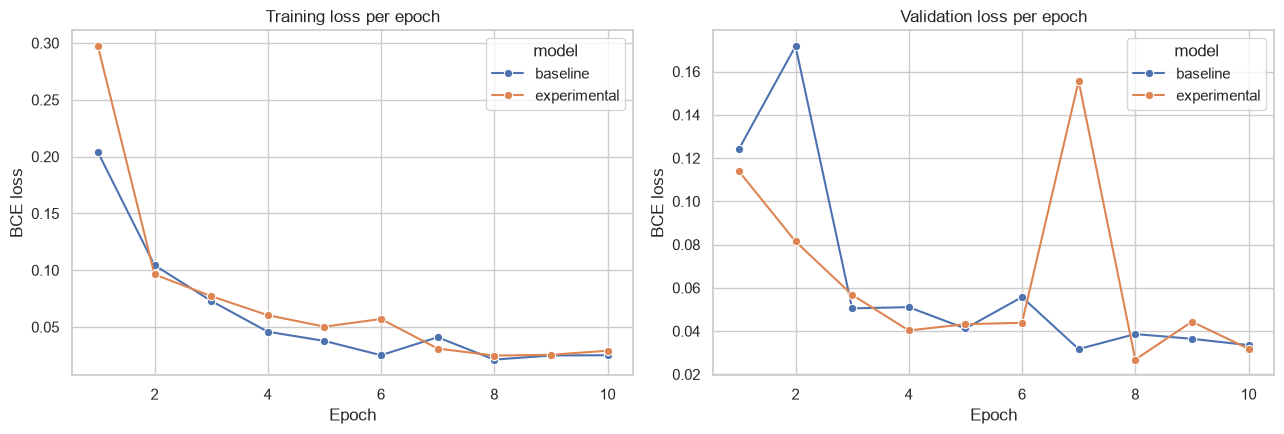

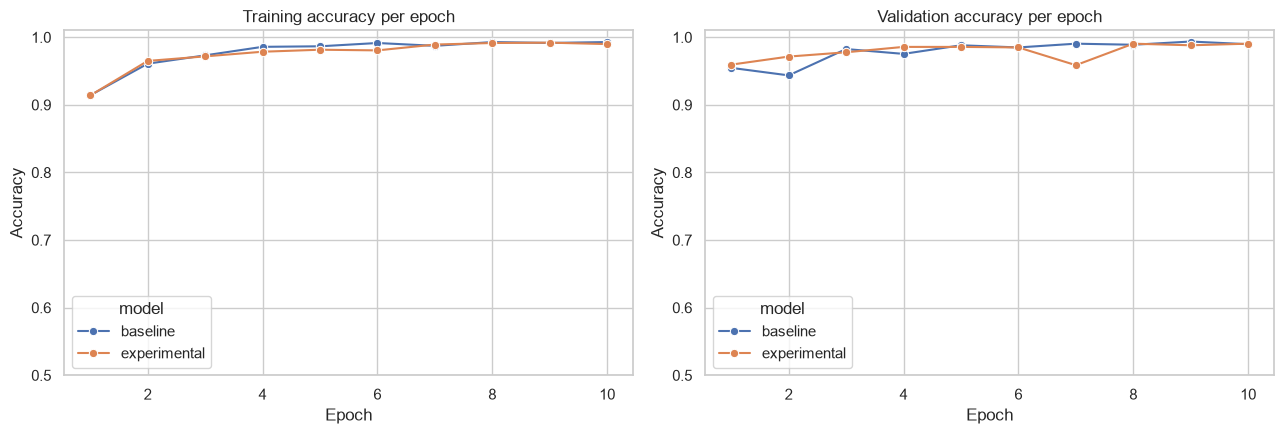

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.lineplot(data=hist_df, x='epoch', y='train_loss', hue='model', marker='o', ax=axes[0])
axes[0].set_title('Training loss per epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE loss')

sns.lineplot(data=hist_df, x='epoch', y='val_loss', hue='model', marker='o', ax=axes[1])
axes[1].set_title('Validation loss per epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('BCE loss')

plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.lineplot(data=hist_df, x='epoch', y='train_acc', hue='model', marker='o', ax=axes[0])
axes[0].set_title('Training accuracy per epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.01)

sns.lineplot(data=hist_df, x='epoch', y='val_acc', hue='model', marker='o', ax=axes[1])
axes[1].set_title('Validation accuracy per epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.01)

plt.tight_layout(); plt.show()

**Reading the curves:** BatchNorm's typical signature is faster early-epoch
convergence (lower train loss from epoch 1) and a tighter train/val gap
(regularization-like effect). If the curves overlap, the architectural
change was a wash on this dataset — also a valid finding.

## 7. Confusion matrix + per-class metrics

Binary occupancy, threshold at logit 0. Use the trained model objects
returned by `train.fit()` so we don't retrain.

In [40]:
def collect_preds(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            logit = model(x.to(DEVICE))
            pred = (logit.cpu() > 0).float()
            y_true.append(y); y_pred.append(pred)
    return torch.cat(y_true).numpy().ravel(), torch.cat(y_pred).numpy().ravel()

cms = {}
for name, r in results.items():
    yt, yp = collect_preds(r['model'], test_loader)
    cm = pd.crosstab(pd.Series(yt, name='true'), pd.Series(yp, name='pred'))
    cms[name] = (cm, yt, yp)
    print(f'{name}: positive_rate={yp.mean():.3f}, true_positive_rate={(yp[yt == 1] == 1).mean():.3f}')

baseline: positive_rate=0.668, true_positive_rate=0.986
experimental: positive_rate=0.681, true_positive_rate=0.998


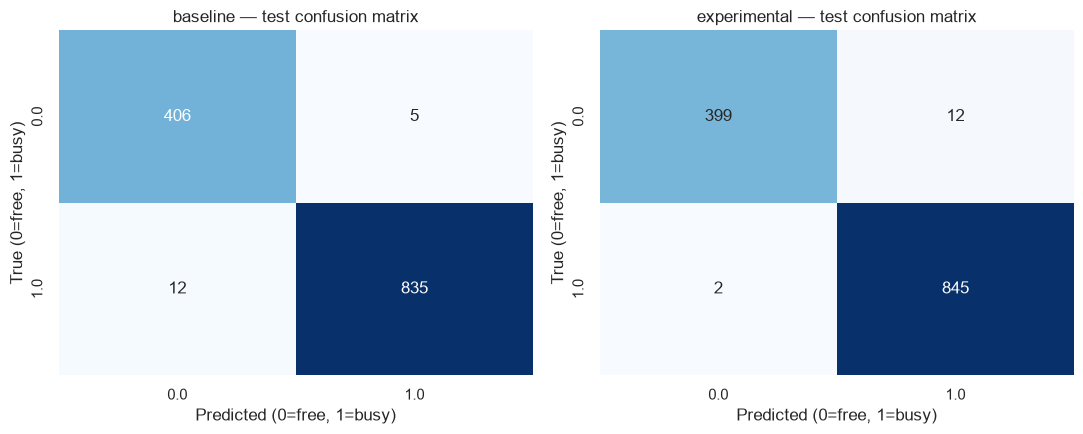

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, (cm, _, _)) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'{name} — test confusion matrix')
    ax.set_xlabel('Predicted (0=free, 1=busy)')
    ax.set_ylabel('True (0=free, 1=busy)')
plt.tight_layout(); plt.show()

In [42]:
def per_class(y_true, y_pred):
    rows = []
    for cls, name in [(0, 'free'), (1, 'busy')]:
        tp = int(((y_pred == cls) & (y_true == cls)).sum())
        fp = int(((y_pred == cls) & (y_true != cls)).sum())
        fn = int(((y_pred != cls) & (y_true == cls)).sum())
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall    = tp / (tp + fn) if tp + fn else 0.0
        rows.append({'class': name, 'precision': precision, 'recall': recall, 'support': int((y_true == cls).sum())})
    return pd.DataFrame(rows)

for name, (_, yt, yp) in cms.items():
    print(f'\n{name}')
    display(per_class(yt, yp))


baseline


,class,precision,recall,support
0,free,0.971292,0.987835,411
1,busy,0.994048,0.985832,847



experimental


,class,precision,recall,support
0,free,0.995012,0.970803,411
1,busy,0.985998,0.997639,847


## 8. Interpretation

**What the experiment tests.** BaselineCNN and ExperimentalCNN share depth,
channel widths, pooling, head, loss, optimizer, learning rate, augmentation,
batch size, and data split (same SEED=42 indices). The **only** difference
is `BatchNorm2d` after every conv in the experimental run. The diff cell
above shows this line-for-line.

**What to look for in the numbers.**

1. **Final test accuracy / loss** — does BatchNorm end at a better operating point?
2. **Best validation accuracy** — model-selection signal (we do not retune on test).
3. **Convergence speed** — do curves in §6 show BatchNorm reaching high accuracy earlier?
4. **Train/val gap** — does BatchNorm close it (regularization-like) or leave it unchanged?
5. **Per-class precision/recall** — given the ~2:1 imbalance toward `busy`, watch
   whether either model silently trades recall on `free` for accuracy on `busy`.

**Honest-reporting checklist**
- No cross-camera holdout. Cameras A and B have different parking-lot
  geometry, so a model trained only on A could plausibly do worse on B.
  The current split is per-patch (i.i.d.); a per-camera holdout would
  test domain shift.

**Tie-in to P7 (security-ops copilot).** Binary occupancy from a fixed
camera is the simplest possible surveillance event. The fusion layer
in P7 ingests higher-level events; this notebook demonstrates that the
PyTorch pattern (torch Dataset → random_split → DataLoader → model →
fit → CSV history → confusion matrix) is end-to-end runnable, and that
BatchNorm is a viable regularization lever for similar CNNs used inside
P7's stack if one is ever needed.

## 9. Reproducibility

- Single `SEED = 42` constant in `src/dataset.py` and `src/train.py`; both
  models use the same split indices.
- `requirements.txt` will be generated via `pip freeze` from `cnn_env`
  (torch 2.12.1+cpu, torchvision 0.27.1+cpu).
- `python src/train.py ...` reproduces the same metrics CSVs without
  running the notebook (see `src/train.py: main()`).
- Notebook is runnable top-to-bottom in `cnn_env`:

```bash
cnn_env/Scripts/jupyter-lab
```